## **_Sample Modeling V5.2_**
- for Reinforcement Learning
- using torch.nn
- 이것은 ANFIS"(Adaptive Neuro-Fuzzy Inference System) 또는 Neuro-Fuzzy"를 적용한 모델입니다.
  - Neuro-Fuzzy 방식: 전문가 데이터를 기반으로 Fuzzy의 멤버십 함수(삼각형의 폭, 중심점)를 역전파(Backpropagation) 알고리즘으로 미세 조정합니다.
  - 효과: "추우면 RPM을 낮춘다"는 규칙은 유지하되, "정확히 몇 도부터 추운지"를 데이터에 맞춰 최적화합니다.
  - 장점
    - 설명 가능성(Explainability): 학습이 끝난 후에도 "아, 모델이 '춥다'의 기준을 75도에서 78도로 수정했구나"라고 파악할 수 있습니다.
    - 정밀도: 사람이 손으로 튜닝한 Fuzzy보다 훨씬 부드럽고 정확한 제어 곡선을 가집니다.
    - 안전성: 강화학습처럼 무작위 탐색을 하지 않고, 전문가의 가이드라인(BC) 안에서 움직이므로 시스템 폭주 위험이 낮습니다.
- pip install numpy pandas tensor ipykernel torch scikit-learn gymnasium stable_baselines3 scikit-fuzzy

In [1]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------
import os
import sys
from pathlib import Path
from datetime import datetime

version = "v5.2"
csv_file_pathname = lambda: f".{os.sep}data{os.sep}fuzzy_dryer_sensor_{version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
model_path_name = lambda: f".{os.sep}model{os.sep}fuzzy_dryer_{version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
global_num_samples = 51200
parent_dir = os.path.dirname(os.getcwd())
project_home_dir = str(Path.cwd().parent.parent)
venv_name = f"samplemodeling{version.replace('.', '_')}"

reward_gen_fn="lib/reward/dryer_oven/gen_reward_v1.py"
reward_gen_fn = reward_gen_fn.replace("/", os.sep)
reward_gen_fn_pythonfile = project_home_dir + os.sep + reward_gen_fn
simulation_cls_pathname = "lib/simulate/dryer_oven_simulation.py"
simulation_cls_pathname = simulation_cls_pathname.replace("/", os.sep)
simulation_cls_pathname = project_home_dir + os.sep + simulation_cls_pathname


In [2]:
# ----------------------------------------------------
# 개발 환경 초기화
# 한 번만 호출하여 주십시요.


# 1.1 set pythonpath to import from parent directory
def _init_environ():
    python_path = os.environ.get("PYTHONPATH")
    if python_path is None:
        python_path = ""
    sys.path.append(parent_dir)
    sys.path.append(project_home_dir)
    python_lib_path = [
        f'{project_home_dir}{os.sep}{venv_name}{os.sep}{"Lib" if sys.platform == "win32" else "lib"}{os.sep}site-packages',
        project_home_dir,
        python_path
    ]
    os.environ["PYTHONPATH"] = ";".join(python_lib_path)

    os.environ["CLEARML_WEB_HOST"] = "http://172.16.8.168:8080/"
    os.environ["CLEARML_API_HOST"] = "http://172.16.8.168:8008/"
    os.environ["CLEARML_FILES_HOST"] = "http://172.16.8.168:8081"
    os.environ["CLEARML_API_ACCESS_KEY"] = "SIJ8V8YP9PL25YEAVAWGP9NV11TMOQ"
    os.environ["CLEARML_API_SECRET_KEY"] = "6x_MEHvgrUv9-TFFDrE9BE7vb3JYOXDWq4kQtqbd58nQ5pqHEGMt6qQXxF7_HCyzq7E"

_init_environ()


In [3]:
!echo $PYTHONPATH
from lib.simulate.dryer_oven_data_genetate import generate_data_v1
from lib.simulate.dryer_oven_data_genetate_v2 import generate_data_v2
from lib.simulate.dryer_oven_data_genetate_v3 import generate_data_v3

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25
drop_envs = [(0.4, 100, 30), (0.5, 200, 40)]
spike_envs = [(0.6, 300, 50), (0.7, 200, 40), (0.8, 200, 70)]
# drop_envs = []
# spike_envs = []

verbose = 0


gen_functions = {"v1": generate_data_v1, "v2": generate_data_v2, "v3": generate_data_v3}
cur_version = "v3"

stored_data_file_pathname = gen_functions[cur_version](drop_envs=drop_envs,
                                                       spike_envs=spike_envs,
                                                       csv_file_pathname=csv_file_pathname(),
                                                       num_samples=global_num_samples,
                                                       target_temp=target_temp,
                                                       initial_temp=initial_temp,
                                                       verbose=verbose)
print(f"Data stored in: {stored_data_file_pathname}")

/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/samplemodelingv5_2/lib/site-packages;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks;
curr_int_temp = 25
건조기 센서 가상 데이터 생성 완료!
데이터 샘플 (목표 온도: 80도):
Data stored in: ./data/fuzzy_dryer_sensor_v5.2_20260401_090804.csv


#### Step 2 BC 학습

In [29]:
temp_error = lambda x,b: x - b
humidity = lambda x: x / 100.0
weight = lambda x: x / 100.0
out_temp = lambda x: x / 40.0
pressure = lambda x: (x - 1013.0)/50.0
fan_rpm = lambda x: (x / 3500.0)

In [38]:
import pandas as pd
import torch
# 1. 전문가 데이터 로드 및 전처리
def load_expert_data(csv_file_pathname, target_temp):
    df = pd.read_csv(csv_file_pathname)
    # 입력: 오차(temp-80), 출력: 전문가의 액션(RPM_Adjust)
    X = np.zeros((len(df), 6))
    X[:, 0] = df['inner_temp'] - target_temp # Error
    action_map = {0: 0.0, 1: 1.0, 2: 2.0}
    y = df['user_action'].map(action_map).values.reshape(-1, 1)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [51]:
# 2. Adaptive Neuro-Fuzzy 레이어 정의

import torch
import torch.nn as nn

class NeuroFuzzyLayer(nn.Module):
    def __init__(self):
        super(NeuroFuzzyLayer, self).__init__()
        # 멤버십 함수의 중심(mu)과 폭(sigma)과 결론부 파라미터(consequent)를 '학습 가능한 파라미터'로 설정
        # 초기 퍼지 멤버십 함수 파라미터 (사람이 정한 기준값으로 시작)
        # Cold, Target, Hot 세 구간의 중심점(mu)
        # self.mu = nn.Parameter(torch.tensor([-10.0, 0.0, 10.0]))

        self.mu = nn.Parameter(torch.tensor([
            [-5.0, 0.0, 5.0]   # Temp Error
        ]))        
        self.num_mfs = 3
        self.mu_len = len(self.mu)
        # 각 구간의 폭(sigma)
        sigma_width = 0.2
        self.sigma = nn.Parameter(torch.ones(self.mu_len, self.num_mfs) * sigma_width)
        
        # 각 규칙에 대응하는 출력값 (결론부 파라미터)
        sigma_size = self.mu_len * 3
        self.consequent = nn.Parameter(torch.randn(sigma_size,3)) # 6변수 x 3멤버십 단순화 모델        

    def forward(self, x):
        # 1. Fuzzification (각 변수별 멤버십 등급 계산)
        # x: [batch, 5], mu: [5, 3]
        batch_size = x.shape[0]
        all_grade = []
        for i in range(self.mu_len):
            # 가우시안 멤버십 함수
            grade = torch.exp(-0.5 * ((x[:, i:i+1] - self.mu[i]) / self.sigma[i]) ** 2)
            all_grade.append(grade)
        
        # # 2. Rule Base (단순 선형 결합 방식의 퍼지 추론)
        # all_grades = torch.cat(all_grade, dim=1) # [batch, 15]
        # 2. 모든 멤버십 등급 결합 (Concatenate)
        # 결과 shape: [batch, 18] (6개 변수 * 3개 등급)
        firing_strengths = torch.cat(all_grade, dim=1)

        # 3. 정규화 (Normalization)
        # weights = all_grades / (torch.sum(all_grades, dim=1, keepdim=True) + 1e-8)
        sum_strengths = torch.sum(firing_strengths, dim=1, keepdim=True) + 1e-8
        norm_strengths = firing_strengths / sum_strengths
        
        # 4. Defuzzification (가중 평균)
        # [수정] 각 액션별 점수(Logits) 계산: [batch, 3]
        out = torch.mm(norm_strengths, self.consequent)
        # return torch.sigmoid(out) * 2.0 
        return out


# 이 레이어를 포함한 모델을 구성하고 
# 전문가의 Action과 비교하여 Loss를 줄이는 방식으로 학습(BC)을 진행합니다.


In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

# 3. BC(Behavior Cloning) 학습
def train(csv_file_pathname, epochs=50, verbose=0):
    X_train, y_train = load_expert_data(csv_file_pathname=csv_file_pathname, target_temp=80)
    model = NeuroFuzzyLayer()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    if verbose > 0:
        print("퍼지 파라미터 최적화 시작...")
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_train)
        # action = torch.argmax(output, dim=1)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0 and verbose > 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

    # 학습된 파라미터 확인
    if verbose > 0:
        print("\n--- 학습 완료된 퍼지 파라미터 ---")
        print(f"중심점(mu): {model.mu.data.numpy()}")
        print(f"폭(sigma): {model.sigma.data.numpy()}")
    return model

In [53]:
# 테스트

def single_test(count, test_input, csv_file_pathname, epochs=50):
    trained_fuzzy = train(csv_file_pathname=csv_file_pathname)
    prediction = trained_fuzzy(test_input)
    action = torch.argmax(prediction, dim=1)
    print(f'[{count:02d}] action = {type(action)}, {int(action)}, prediction={prediction}')


test_input = torch.tensor([[-10.0, 80.0/100.0, 39.0/5.0, 22, 0, 1500/1500], ])
epochs=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

"""
epochs=50인 경우를 10 번 시행 할 경우의 액션 변화 관찰
"""
print(f"{'*'*20}\nepochs=50인 경우를 10 번 시행 할 경우의 액션 변화 관찰\n{'*'*20}")
repeat_cnt = 10
for i in range(repeat_cnt):
    single_test(count=i, test_input=test_input, csv_file_pathname=stored_data_file_pathname)

"""
epochs를 10씩 증가 하면서 액션 변화 관찰
"""
print(f"{'*'*20}\nepochs를 10씩 증가 하면서 액션 변화 관찰\n{'*'*20}")
for i in range(len(epochs)):
    single_test(count=i, test_input=test_input, csv_file_pathname=stored_data_file_pathname, epochs=epochs[i])

********************
epochs=50인 경우를 10 번 시행 할 경우의 액션 변화 관찰
********************
[00] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[01] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[02] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[03] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[04] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[05] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[06] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[07] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[08] action = <class 'torch.Tensor'>, 0, prediction=tensor([[0., 0., 0.]], grad_fn=<MmBackward0>)
[09] action = <class 'torch.Tensor'>, 

#### Step 3 학습 모델로 제어 시뮬레이션

hit
hit_point = 14


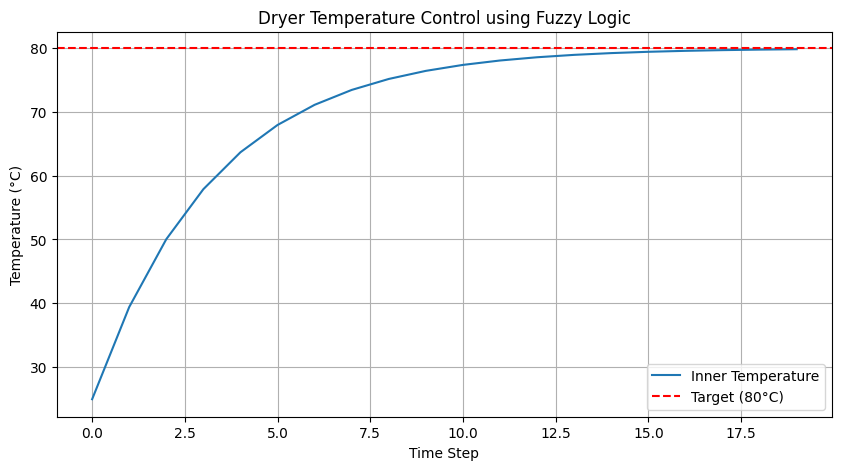

In [77]:
from lib.simulate.dryer_oven_simulation import DryerOvenSimulation
import torch
import matplotlib.pyplot as plt
from lib.simulate.dryer_oven_simulation import DryerOvenSimulation
import torch
import matplotlib.pyplot as plt
from lib.types import unpack_nptype

max_repeat_cnt = 20
initial_temp = 25.0
const_heater_input = 15.5

simulation = DryerOvenSimulation(use_ts=False,
                                 target_temp=80.0,
                                 initial_temp=initial_temp,
                                 initial_weight=80,
                                 dry_weight=20,
                                 debug=False)
init_state = [
            25.0,   # inner_temp 0
            -55.0,  # error      1
            80.0,   # humidity   2
            39.0,   # weight     3
            22.0,   # outer_temp 4
            1013.0, # pressure   5
            1500.0] # fan_rpm    6
history = []
state = init_state
convergence_cnt = 0
convergenced_cnt = 0
convergenced_stats = False
hit_point=0

for i in range(max_repeat_cnt):
    sensor_data = [unpack_nptype(state[1])]
    history.append(state[0])
    sensor_data = torch.tensor([sensor_data])
    raw_action = trained_fuzzy(sensor_data)
    action = int(torch.argmax(raw_action, dim=1))
    state = simulation.step(action=action, state=state, heater_input=const_heater_input)
    state = list(state.values())
    inner_temp = state[0]

    # 수렴 위치 측정
    if abs(inner_temp - target_temp) < 1.5:
        convergenced_stats = True
        convergence_cnt += 1
        if convergence_cnt > 3 and convergenced_stats == True and hit_point == 0:
            print(f'hit')
            convergenced_cnt
            hit_point = i
    else:
        convergenced_stats = False
        convergence_cnt = 0
        hit_point = 0

print(f'hit_point = {hit_point}')

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(history, label='Inner Temperature')
plt.axhline(y=80, color='r', linestyle='--', label='Target (80°C)')
plt.title('Dryer Temperature Control using Fuzzy Logic')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

##### 4. Test